In [1]:
import numpy as np, pandas as pd
import matplotlib.pylab as plt
import tensorflow as tf
from keras.layers import Input, Dense, LSTM, Embedding, Dropout, Activation
from keras.models import Model
from keras import initializers, optimizers
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import ModelCheckpoint
import seaborn, re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
print('tf version ' + tf.version.VERSION)
print('GPU is avaiable' if tf.test.is_gpu_available() else 'GPU is NOT avaialable')

tf version 2.2.0
GPU is avaiable


In [2]:
train_df = pd.read_csv('../input/nlp-getting-started/train.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [3]:
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


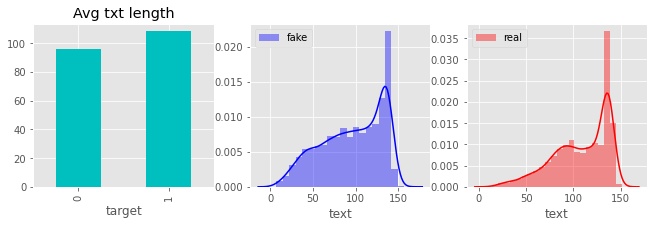

In [4]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(11,3))

train_df.text.str.len().groupby(train_df.target).mean().plot(kind='bar', color='c', ax = axes[0])
axes[0].set_title('Avg txt length')

seaborn.distplot(train_df[train_df.target==0].text.str.len(), ax=axes[1], color='b', label='fake')
axes[1].legend()

seaborn.distplot(train_df[train_df.target==1].text.str.len(), ax=axes[2], color='r', label='real')
axes[2].legend()

In [5]:
def get_ngrams(txts, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range).fit(txts)
    BoW = vec.transform(txts)
    sum_words = BoW.sum(axis=0) 
    wfreq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    wfreq = sorted(wfreq, key = lambda x: x[1], reverse=True)
    return wfreq

train_ngrams = get_ngrams(train_df.text)
print(train_ngrams[:20])

[('http co', 4306), ('https co', 410), ('in the', 308), ('of the', 256), ('û_ http', 217), ('on the', 129), ('to the', 126), ('to be', 108), ('for the', 97), ('at the', 85), ('and the', 79), ('if you', 70), ('you re', 67), ('is the', 67), ('by the', 65), ('going to', 61), ('suicide bomber', 59), ('have been', 55), ('it was', 54), ('this is', 53)]


In [6]:
def remove_url(txt):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',txt)

train_df.text = train_df.text.apply(lambda x: remove_url(x))

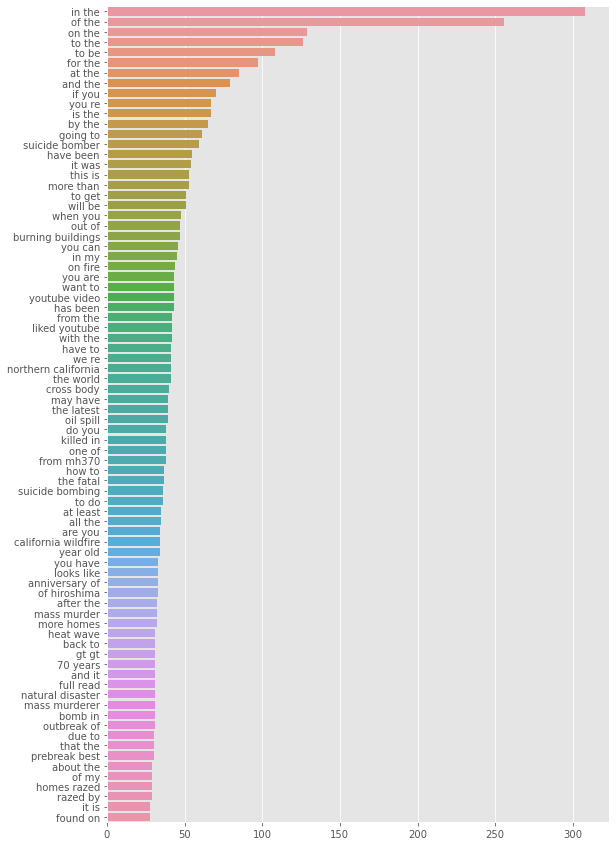

In [7]:
train_ngrams = get_ngrams(train_df.text)

plt.style.use('ggplot')
fig, ax = plt.subplots(1, 1, figsize=(9,15))

word, freq = map(list, zip(*train_ngrams[:80]))
seaborn.barplot(x=freq, y=word);

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(train_df.text.tolist(),
                                                      train_df.target.tolist(),
                                                      test_size=0.2)

## Bag of Words
count_vec = CountVectorizer()
cnt_train = count_vec.fit_transform(X_train)
cnt_valid = count_vec.fit_transform(X_valid)

In [9]:
## TF-IDF
tfidf_vec = TfidfVectorizer()
tfidf_train = tfidf_vec.fit_transform(X_train)
tfidf_valid = tfidf_vec.fit_transform(X_valid)

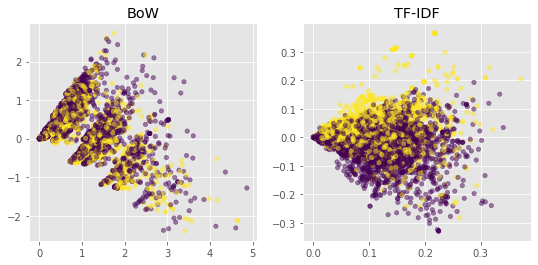

In [10]:
## https://www.kaggle.com/vbmokin/nlp-eda-bag-of-words-tf-idf-glove-bert
from sklearn.decomposition import TruncatedSVD
import matplotlib as mpl

def plot_LSA(data, labels, ax):
    lsa = TruncatedSVD(n_components=2)
    lsa.fit(data)
    lsa_scores = lsa.transform(data)
    color_mapper = {label:idx for idx,label in enumerate(set(labels))}
    color_column = [color_mapper[label] for label in labels]
    ax.scatter(lsa_scores[:,0], lsa_scores[:,1], s=20, alpha=0.5, c=labels)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))          
plot_LSA(cnt_train, y_train, axes[0])
axes[0].set_title('BoW')
plot_LSA(tfidf_train, y_train, axes[1])
axes[1].set_title('TF-IDF');

In [11]:
from nltk import tokenize

docs = []
for txt in train_df.text :
    docs.append([w for w in tokenize.word_tokenize(txt.lower())])

In [12]:
def convert_to_one_hot (y, C) :
    Y = np.eye(C)[y.reshape(-1)]
    return Y

y_train_oh = convert_to_one_hot(np.array(y_train), C=2)
y_valid_oh = convert_to_one_hot(np.array(y_valid), C=2)

In [13]:
def read_glove_vecs (gfile) :
    with open(gfile, 'r') as f :
        words = set()
        word2vec_map = {}
        for line in f :
            line = line.strip().split()
            curr_word = line[0]
            words.add(curr_word)
            word2vec_map[curr_word] = np.array(line[1:], dtype=np.float32)

        ii = 1
        word2idx = {}
        idx2word = {}
        for w in words :
            word2idx[w] = ii
            idx2word[ii] = w
            ii = ii+1

    return word2vec_map, word2idx, idx2word

word2vec_map, word2idx, idx2word = read_glove_vecs('../input/glove-twitter/glove.twitter.27B.100d.txt')

In [14]:
for w in word2vec_map.keys() :
    if len(word2vec_map[w]) ==  len(word2vec_map['love']) - 1:
        word2vec_map[w] = np.pad(word2vec_map[w], [(0,1)], mode='constant') 
print(word2vec_map['love'])

[-4.8371e-01 -2.7318e-01 -4.6840e-02  7.0274e-01 -5.6301e-01 -1.7214e-01
  8.1775e-01 -6.6641e-02  2.0224e-02 -2.3878e-01 -1.6122e-02 -1.7875e-01
 -4.9281e+00 -4.0272e-01 -4.1190e-01 -1.4570e-01  1.8508e-01 -1.9116e-01
 -8.4608e-01  6.5378e-01  1.2370e-01  4.8835e-02 -3.3709e-01  2.5834e-01
  4.7729e-01 -8.8145e-01 -1.3083e-01  7.9499e-01  8.6216e-02 -9.1803e-01
 -9.6671e-01 -4.8309e-01 -4.0963e-01  1.6920e-01  2.3241e-01 -2.0524e-02
  2.2267e-01 -2.6763e-01  1.4378e-01 -4.6547e-02 -1.1726e+00 -3.5298e-02
  2.8347e-01  4.3446e-01  1.8472e-01  3.3065e-01  6.7848e-02 -7.6485e-01
  1.8351e-01 -6.4361e-01 -7.5015e-01 -4.2583e-02  2.4262e-01 -6.4108e-01
  6.9741e-01 -2.3133e-01 -2.1454e-01  3.1040e-01  2.3161e-01  6.8397e-02
  8.1428e-02 -3.9331e-01 -1.0927e+00 -4.2618e-02 -9.6970e-02  3.1243e-01
 -1.0463e+00  2.8207e-01 -7.2446e-01  3.1422e-01  5.9191e-01 -2.7716e-01
 -8.3745e-02 -3.0487e-01  4.0743e-01  1.6906e-02 -5.3021e-01 -4.0651e-01
 -2.8332e-01  3.5181e-01  1.4475e+00  1.0493e-01 -9

In [15]:
def sente2indices (X, word2idx, maxLen=50) :
    m = np.shape(X)[0]
    ids = np.zeros((m, maxLen))
    for ii in range(m) :
        words = X[ii].lower().split()
        for idx, w in enumerate(words) :
            if w in word2idx.keys() :
                ids[ii, idx] = word2idx[w]

    return ids

In [16]:
def create_embedding_layer (word2vec_map, word2idx) :
    vocab_len = len(word2idx) + 1
    emb_dim = np.shape(word2vec_map['love'])[0]
    emb_mat = np.zeros((vocab_len, emb_dim))
    for w, ii in word2idx.items() :
        emb_mat[ii, :] = word2vec_map[w]

    embedding_layer = Embedding(vocab_len, emb_dim, trainable=False)
    embedding_layer.build((None,))
    embedding_layer.set_weights([emb_mat])
    return embedding_layer

In [17]:
def txt_cls (input_shape, word2vec_map, word2idx) :
    X_input = Input(input_shape)
    embedding_layer = create_embedding_layer(word2vec_map, word2idx)
    X = embedding_layer(X_input)
    X = LSTM(units=32, activation='tanh', use_bias=True, bias_initializer='zeros',
        kernel_initializer='glorot_uniform', return_sequences=True)(X)
    X = Dropout(0.2)(X)
    X = LSTM(units=32, activation='tanh', use_bias=True, bias_initializer='zeros',
        kernel_initializer='glorot_uniform', return_sequences=False)(X)
    X = Dropout(0.2)(X)
    X = Dense(2, activation=None, use_bias=True, bias_initializer='zeros',
        kernel_initializer='glorot_uniform')(X)
    X = Activation('sigmoid')(X)

    model = Model(inputs=X_input, outputs=X)

    return model

In [18]:
## 1
maxLen = 50
clsModel = txt_cls((maxLen,), word2vec_map, word2idx)
clsModel.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 50)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 50, 100)           119351500 
_________________________________________________________________
lstm (LSTM)                  (None, 50, 32)            17024     
_________________________________________________________________
dropout (Dropout)            (None, 50, 32)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 32)                8320      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense (Dense)                (None, 2)                 66    

In [19]:
## 2
optim = optimizers.Adam(lr=0.0005)
clsModel.compile(loss='categorical_crossentropy', optimizer=optim, metrics=['accuracy'])

In [20]:
## 3
cp_fpath = "clsModel.hdf5"
mdlcp_cb = ModelCheckpoint(cp_fpath, monitor='val_accuracy', mode='max', save_best_only=True,
                          save_weights_only=True, verbose=1)

X_train_ids = sente2indices(X_train, word2idx, maxLen)
X_valid_ids = sente2indices(X_valid, word2idx, maxLen)
clsRes = clsModel.fit(x=X_train_ids, 
                      y=y_train_oh,
                      validation_data=(X_valid_ids, y_valid_oh),
                      epochs=100, 
                      batch_size=512, 
                      shuffle=True,
                      callbacks=[mdlcp_cb],
                      verbose=1)

Epoch 1/100
10/12 [========================>.....] - ETA: 0s - loss: 0.6915 - accuracy: 0.5592
Epoch 00001: val_accuracy improved from -inf to 0.58240, saving model to clsModel.hdf5
12/12 [==============================] - 2s 208ms/step - loss: 0.6912 - accuracy: 0.5611 - val_loss: 0.6869 - val_accuracy: 0.5824
Epoch 2/100
11/12 [==========================>...] - ETA: 0s - loss: 0.6823 - accuracy: 0.5700
Epoch 00002: val_accuracy did not improve from 0.58240
12/12 [==============================] - 0s 15ms/step - loss: 0.6823 - accuracy: 0.5673 - val_loss: 0.6639 - val_accuracy: 0.5824
Epoch 3/100
11/12 [==========================>...] - ETA: 0s - loss: 0.6472 - accuracy: 0.5945
Epoch 00003: val_accuracy improved from 0.58240 to 0.74393, saving model to clsModel.hdf5
12/12 [==============================] - 2s 158ms/step - loss: 0.6414 - accuracy: 0.6069 - val_loss: 0.5803 - val_accuracy: 0.7439
Epoch 4/100
10/12 [========================>.....] - ETA: 0s - loss: 0.5714 - accuracy: 0.7

Text(0, 0.5, 'accuracy')

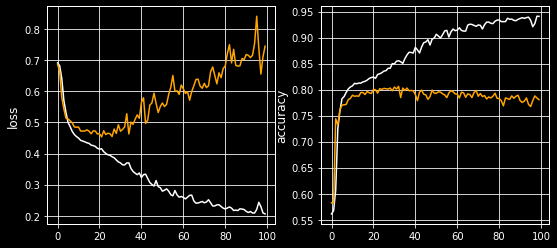

In [21]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(9,4))

axes[0].plot(clsRes.history['loss'], 'w', label='train')
axes[0].plot(clsRes.history['val_loss'], 'orange', label='valid')
axes[0].set_ylabel('loss')

axes[1].plot(clsRes.history['accuracy'], 'w', label='train')
axes[1].plot(clsRes.history['val_accuracy'], 'orange', label='valid')
axes[1].set_ylabel('accuracy')

In [22]:
clsModel_json = clsModel.to_json()
with open('clsModel.json', 'w') as myfile:
     myfile.write(clsModel_json)

In [23]:
clsModel = txt_cls((maxLen,), word2vec_map, word2idx)
clsModel.compile(loss='categorical_crossentropy', optimizer=optim, metrics=['accuracy'])
clsModel.load_weights('/kaggle/working/clsModel.hdf5')

In [24]:
# print mislabelled examples
pred = clsModel.predict(X_valid_ids)
for ii in range(50):
    x = X_valid_ids
    num = np.argmax(pred[ii])
    if(num != y_valid[ii]):
        print('pred: ' + str(num) + 
              ', true: ' + str(y_valid[ii]) + 
               ' --> ', X_valid[ii] + '\n')

pred: 0, true: 1 -->  Strengthening partnerships #AfterHaiyan  #Haiyan #YolandaPh #Philippines #livelihood #disasterrecovery #disaster

pred: 0, true: 1 -->  Windstorm lastingness perquisite - acquiesce in a twister retreat: ZiUW 

pred: 0, true: 1 -->  @dirk_trossen 

I've still got some of the snowstorm/hailstorm!

pred: 0, true: 1 -->  They've come back!! &gt;&gt; Flying ant day: Capital deluged by annual swarm of winged insects 

pred: 0, true: 1 -->  So you have a new weapon that can cause un-imaginable destruction.

pred: 0, true: 1 -->  My iPod crashed..... 
#WeLoveYouLouis 
#MTVHottest One Direction

pred: 1, true: 0 -->  Look: #I have collapsed #after attempting to munch an endangered species.

pred: 1, true: 0 -->  Help me survive the zombie apocalypse at the Zombie Fun Run on November 15th.  #teamsurvivors #zombiefunrun2014

pred: 0, true: 1 -->  You happen to conveniently 'forget' about how you Zionists revere and 'honour' mass murderer Baruch Goldstein.  



In [25]:
# print correctly labelled examples
pred = clsModel.predict(X_valid_ids)
for ii in range(20):
    x = X_valid_ids
    num = np.argmax(pred[ii])
    if(num == y_valid[ii]):
        print('pred: ' + str(num) + 
              ', true: ' + str(y_valid[ii]) + 
               ' --> ', X_valid[ii] + '\n')

pred: 0, true: 0 -->  Just burst out in actual tears of joy when Cain survived #SummerFate @emmerdale

pred: 1, true: 1 -->  Heat wave warning aa? Ayyo dei. Just when I plan to visit friends after a year.

pred: 0, true: 0 -->  On Thursday at 00:25 we updated our #kml of 2D and 3D #seismic exploration vessels. #offshore #oil 

pred: 0, true: 0 -->  @drag0nking0201 *Screams*don't scare me and its Animatronics

pred: 1, true: 1 -->  DireTube Information ÛÒ Egypt Cyprus and Greece agreed to fightåÊterrorism  

pred: 0, true: 0 -->  #Tigers Wonder how much the upheaval with team is affecting different players tonight?

pred: 1, true: 1 -->  @XHNews We need these plants in the pacific during the cyclone seasons it would help

pred: 0, true: 0 -->  Crack in the path where I wiped out this morning during beach run. Surface wounds on left elbow and right knee. 

pred: 0, true: 0 -->  2 great new recipes; mudslide cake and so sorry stew! #GBBO

pred: 0, true: 0 -->  One of these candidates is 

In [26]:
## 4
test_df = pd.read_csv('../input/nlp-getting-started/test.csv')
test_df.text = test_df.text.apply(lambda x: remove_url(x))

X_test_ids = sente2indices(test_df.text.tolist(), word2idx, maxLen)
y_test_oh = clsModel.predict(X_test_ids)
y_test = [np.argmax(x) for x in y_test_oh]
test_df['target'] = y_test
test_df.head(10)

,id,keyword,location,text,target
0,0,NaN,NaN,Just happened a terrible car crash,1
1,2,NaN,NaN,"Heard about #earthquake is different cities, s...",0
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are...",1
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires,0
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan,1
5,12,NaN,NaN,We're shaking...It's an earthquake,1
6,21,NaN,NaN,They'd probably still show more life than Arse...,0
7,22,NaN,NaN,Hey! How are you?,0
8,27,NaN,NaN,What a nice hat?,0
9,29,NaN,NaN,Fuck off!,0


In [27]:
sub_df = pd.read_csv('../input/nlp-getting-started/sample_submission.csv')
sub_df.target = y_test
sub_df.head()
sub_df.to_csv("sub-glove.csv", index=False, header=True)